# Assignment 3: Predicting Hyderabad Rainfall Using NEX-GDDP-CMIP6 Data

**Model:** ACCESS-CM2  
**Scenario:** SSP2-4.5 (moderate emissions)  
**Historical Period:** 1984–2014  
**Future Period:** 2015–2035  
**Target Area:** Himayat Sagar Catchment (Lat 17.21–17.35, Lon 78.27–78.39)  

**Variables:**
| Variable | Description | Raw Unit | Converted Unit |
|----------|-------------|----------|----------------|
| hurs | Near-Surface Relative Humidity | % | % |
| tas | Daily Near-Surface Air Temperature | K | °C |
| rsds | Shortwave Radiation | W m⁻² | W m⁻² | 
| sfcWind | Daily Mean Near-Surface Wind Speed | m/s | m/s |
| pr | Precipitation | kg m⁻² s⁻¹ | mm/day |

In [28]:
# Common imports used throughout the notebook
import os
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import nex_gddp
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Constants
BBOX = (78.271841, 17.212690, 78.388705, 17.361425)
DATA_DIR = "./data"
VARIABLES = ["hurs", "tas", "rsds", "sfcWind", "pr"]
HIST_YEARS = list(range(1984, 2015))
FUTURE_YEARS = list(range(2015, 2036))
MODEL = "ACCESS-CM2"
SCENARIO = "ssp245"

# Column name mapping (raw -> converted)
UNIT_MAP = {
    "hurs": "Relative Humidity (%)",
    "tas": "Average Temperature (°C)",
    "rsds": "Shortwave Radiation (W/m^2)",
    "sfcWind": "Wind Speed (m/s)",
    "pr": "Precipitation (mm/day)"
}

def load_nc_var(data_dir, model, scenario, var):
    """Load a single variable from NetCDF files and return a spatially-averaged time series."""
    var_dir = Path(data_dir) / model / scenario / var
    files = sorted(var_dir.glob("*.nc"))
    if not files:
        print(f"  ⚠ No files found for {var} in {scenario}.")
        return None
    ds = xr.open_mfdataset(files, use_cftime=True, engine='netcdf4')
    df = ds[var].to_dataframe().reset_index()
    df_time = df.groupby('time')[var].mean().reset_index()
    return df_time

def load_and_merge(data_dir, model, scenario, variables):
    """Load multiple variables and merge into one DataFrame."""
    dfs = []
    for var in variables:
        df_var = load_nc_var(data_dir, model, scenario, var)
        if df_var is not None and not df_var.empty:
            dfs.append(df_var)
    if not dfs:
        return pd.DataFrame()
    merged = dfs[0]
    for i in range(1, len(dfs)):
        merged = merged.merge(dfs[i], on='time', how='inner')
    merged['time'] = pd.to_datetime([str(t) for t in merged['time']])
    merged.dropna(inplace=True)
    return merged

def convert_units(df):
    """Convert raw CMIP6 units to human-readable units in-place."""
    for col in ['tas']:
        if col in df.columns:
            df[col] = df[col] - 273.15
    if 'pr' in df.columns:
        df['pr'] = df['pr'] * 86400
    df.rename(columns=UNIT_MAP, inplace=True)
    return df


def cap_outliers_hybrid(df, columns):
    """
    Replace outliers:
    - Precipitation: Cap at 500 mm/day (and minimum 0).
    - Other variables: Cap at max/min actual values within 3-sigma bounds.
    """
    df_capped = df.copy()
    for col in columns:
        if col == "Precipitation (mm/day)":
            # Hard threshold for rainfall
            df_capped.loc[df_capped[col] > 500, col] = 500
            df_capped.loc[df_capped[col] < 0, col] = 0
        else:
            # 3-sigma rule for all other variables
            mean_val = df_capped[col].mean()
            std_val = df_capped[col].std()
            
            lower_bound = mean_val - (3 * std_val)
            upper_bound = mean_val + (3 * std_val)
            
            # Find the actual min and max values strictly within the bounds
            valid_data = df_capped[(df_capped[col] >= lower_bound) & (df_capped[col] <= upper_bound)][col]
            
            if not valid_data.empty:
                actual_min = valid_data.min()
                actual_max = valid_data.max()
                
                # Replace outliers with these actual min/max values
                df_capped.loc[df_capped[col] < lower_bound, col] = actual_min
                df_capped.loc[df_capped[col] > upper_bound, col] = actual_max
        
    return df_capped


print("✓ Setup complete.")

✓ Setup complete.


---
## Step 1: Download Historical Data (1984–2014)

In [2]:
print(f"Downloading historical data for {VARIABLES} ({HIST_YEARS[0]}-{HIST_YEARS[-1]})...")
nex_gddp.download(
    variables=VARIABLES,
    years=HIST_YEARS,
    models=MODEL,
    scenarios="historical",
    bbox=BBOX,
    output_dir=DATA_DIR,
    max_workers=1
)
print("✓ Historical data download complete.")


=== ACCESS-CM2 / historical / hurs ===
  Saved data/ACCESS-CM2/historical/hurs/hurs_ACCESS-CM2_r1i1p1f1_gn_1984.nc
  Saved data/ACCESS-CM2/historical/hurs/hurs_ACCESS-CM2_r1i1p1f1_gn_1985.nc
  Saved data/ACCESS-CM2/historical/hurs/hurs_ACCESS-CM2_r1i1p1f1_gn_1986.nc
  Saved data/ACCESS-CM2/historical/hurs/hurs_ACCESS-CM2_r1i1p1f1_gn_1987.nc
  Saved data/ACCESS-CM2/historical/hurs/hurs_ACCESS-CM2_r1i1p1f1_gn_1988.nc
  Saved data/ACCESS-CM2/historical/hurs/hurs_ACCESS-CM2_r1i1p1f1_gn_1989.nc
  Saved data/ACCESS-CM2/historical/hurs/hurs_ACCESS-CM2_r1i1p1f1_gn_1990.nc
  Saved data/ACCESS-CM2/historical/hurs/hurs_ACCESS-CM2_r1i1p1f1_gn_1991.nc
  Saved data/ACCESS-CM2/historical/hurs/hurs_ACCESS-CM2_r1i1p1f1_gn_1992.nc
  Saved data/ACCESS-CM2/historical/hurs/hurs_ACCESS-CM2_r1i1p1f1_gn_1993.nc
  Saved data/ACCESS-CM2/historical/hurs/hurs_ACCESS-CM2_r1i1p1f1_gn_1994.nc
  Saved data/ACCESS-CM2/historical/hurs/hurs_ACCESS-CM2_r1i1p1f1_gn_1995.nc
  Saved data/ACCESS-CM2/historical/hurs/hurs_ACC

---
## Step 2: Parse & Convert Historical Data → `historical_data.csv`

In [29]:
print("Loading and merging historical NetCDF files...")
hist_df = load_and_merge(DATA_DIR, MODEL, "historical", VARIABLES)

if hist_df.empty:
    raise RuntimeError("No historical data loaded. Ensure download step completed.")

hist_df = convert_units(hist_df)

# ---- REMOVE OUTLIERS ----
# Apply hybrid capping (500mm for rain, 3-sigma for others)
climate_cols = list(UNIT_MAP.values())
hist_df = cap_outliers_hybrid(hist_df, climate_cols)

# ---- ADD LAG VARIABLES ----
# Ensure data is sorted by time before shifting
hist_df = hist_df.sort_values('time').reset_index(drop=True)
hist_df['Rainfall Lag 1 (mm/day)'] = hist_df['Precipitation (mm/day)'].shift(1)
hist_df['Rainfall Lag 2 (mm/day)'] = hist_df['Precipitation (mm/day)'].shift(2)

# Drop the first 2 rows which will have NaN values due to the shift
hist_df.dropna(inplace=True)

hist_df.to_csv("historical_data.csv", index=False)
print(f"✓ Saved historical_data.csv ({len(hist_df)} rows)")
hist_df.head()

Loading and merging historical NetCDF files...


/tmp/ipykernel_33201/1655107267.py:40: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  ds = xr.open_mfdataset(files, use_cftime=True, engine='netcdf4')
/tmp/ipykernel_33201/1655107267.py:40: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  ds = xr.open_mfdataset(files, use_cftime=True, engine='netcdf4')
/tmp/ipykernel_33201/1655107267.py:40: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the

✓ Saved historical_data.csv (9860 rows)


,time,Relative Humidity (%),Average Temperature (°C),Shortwave Radiation (W/m^2),Wind Speed (m/s),Precipitation (mm/day),Rainfall Lag 1 (mm/day),Rainfall Lag 2 (mm/day)
2,1984-01-03 12:00:00,41.546024,24.689819,224.445282,2.133948,0.0,0.0,0.0
3,1984-01-04 12:00:00,41.870140,24.261810,229.912476,2.306937,0.0,0.0,0.0
4,1984-01-05 12:00:00,44.974174,24.353363,215.865967,2.649165,0.0,0.0,0.0
5,1984-01-06 12:00:00,49.286324,24.691376,188.399811,2.999207,0.0,0.0,0.0
6,1984-01-07 12:00:00,46.965607,25.261658,214.700058,3.232219,0.0,0.0,0.0


---
## Step 3: Download Future Data (2015–2035, SSP2-4.5)

In [4]:
print(f"Downloading future data for {VARIABLES} ({FUTURE_YEARS[0]}–{FUTURE_YEARS[-1]}), scenario: {SCENARIO}...")
nex_gddp.download(
    variables=VARIABLES,
    years=FUTURE_YEARS,
    models=MODEL,
    scenarios=SCENARIO,
    bbox=BBOX,
    output_dir=DATA_DIR,
    max_workers=1
)
print("✓ Future data download complete.")


=== ACCESS-CM2 / ssp245 / hurs ===
  Saved data/ACCESS-CM2/ssp245/hurs/hurs_ACCESS-CM2_r1i1p1f1_gn_2015.nc
  Saved data/ACCESS-CM2/ssp245/hurs/hurs_ACCESS-CM2_r1i1p1f1_gn_2016.nc
  Saved data/ACCESS-CM2/ssp245/hurs/hurs_ACCESS-CM2_r1i1p1f1_gn_2017.nc
  Saved data/ACCESS-CM2/ssp245/hurs/hurs_ACCESS-CM2_r1i1p1f1_gn_2018.nc
  Saved data/ACCESS-CM2/ssp245/hurs/hurs_ACCESS-CM2_r1i1p1f1_gn_2019.nc
  Saved data/ACCESS-CM2/ssp245/hurs/hurs_ACCESS-CM2_r1i1p1f1_gn_2020.nc
  Saved data/ACCESS-CM2/ssp245/hurs/hurs_ACCESS-CM2_r1i1p1f1_gn_2021.nc
  Saved data/ACCESS-CM2/ssp245/hurs/hurs_ACCESS-CM2_r1i1p1f1_gn_2022.nc
  Saved data/ACCESS-CM2/ssp245/hurs/hurs_ACCESS-CM2_r1i1p1f1_gn_2023.nc
  Saved data/ACCESS-CM2/ssp245/hurs/hurs_ACCESS-CM2_r1i1p1f1_gn_2024.nc
  Saved data/ACCESS-CM2/ssp245/hurs/hurs_ACCESS-CM2_r1i1p1f1_gn_2025.nc
  Saved data/ACCESS-CM2/ssp245/hurs/hurs_ACCESS-CM2_r1i1p1f1_gn_2026.nc
  Saved data/ACCESS-CM2/ssp245/hurs/hurs_ACCESS-CM2_r1i1p1f1_gn_2027.nc
  Saved data/ACCESS-CM2/ssp2

---
## Step 4: Parse & Convert Future Data → `future_data.csv`

In [30]:
print("Loading and merging future NetCDF files...")
future_df = load_and_merge(DATA_DIR, MODEL, SCENARIO, VARIABLES)

if future_df.empty:
    raise RuntimeError("No future data loaded. Ensure download step completed.")

future_df = convert_units(future_df)

# ---- REMOVE OUTLIERS ----
# Apply hybrid capping (500mm for rain, 3-sigma for others)
climate_cols = list(UNIT_MAP.values())
future_df = cap_outliers_hybrid(future_df, climate_cols)

# ---- ADD LAG VARIABLES ----
# Ensure data is sorted by time before shifting
future_df = future_df.sort_values('time').reset_index(drop=True)
future_df['Rainfall Lag 1 (mm/day)'] = future_df['Precipitation (mm/day)'].shift(1)
future_df['Rainfall Lag 2 (mm/day)'] = future_df['Precipitation (mm/day)'].shift(2)

# Drop the first 2 rows which will have NaN values due to the shift
future_df.dropna(inplace=True)

future_df.to_csv("future_data.csv", index=False)
print(f"✓ Saved future_data.csv ({len(future_df)} rows)")
future_df.head()

Loading and merging future NetCDF files...


/tmp/ipykernel_33201/1655107267.py:40: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  ds = xr.open_mfdataset(files, use_cftime=True, engine='netcdf4')
/tmp/ipykernel_33201/1655107267.py:40: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  ds = xr.open_mfdataset(files, use_cftime=True, engine='netcdf4')
/tmp/ipykernel_33201/1655107267.py:40: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the

✓ Saved future_data.csv (7668 rows)


,time,Relative Humidity (%),Average Temperature (°C),Shortwave Radiation (W/m^2),Wind Speed (m/s),Precipitation (mm/day),Rainfall Lag 1 (mm/day),Rainfall Lag 2 (mm/day)
2,2015-01-03 12:00:00,47.997837,20.950043,233.181030,3.310719,0.0,0.0,0.0
3,2015-01-04 12:00:00,54.718376,20.759460,212.129532,3.525757,0.0,0.0,0.0
4,2015-01-05 12:00:00,56.582115,20.577179,203.038971,3.238928,0.0,0.0,0.0
5,2015-01-06 12:00:00,54.183197,20.720032,190.671295,3.263402,0.0,0.0,0.0
6,2015-01-07 12:00:00,43.210896,19.855743,214.783600,3.233204,0.0,0.0,0.0


---
## Step 5: Descriptive Statistics & Visualizations

In [31]:
# Reload from CSV to ensure consistency
hist_df = pd.read_csv("historical_data.csv")
hist_df['time'] = pd.to_datetime(hist_df['time'])
future_df = pd.read_csv("future_data.csv")
future_df['time'] = pd.to_datetime(future_df['time'])

plot_vars = list(UNIT_MAP.values())
os.makedirs("visualizations", exist_ok=True)

# ---- Descriptive Statistics ----
print("="*60)
print("   HISTORICAL DATA — Descriptive Statistics (1984–2014)")
print("="*60)
hist_stats = hist_df[plot_vars].describe()
display(hist_stats)

print("\n" + "="*60)
print("   FUTURE DATA — Descriptive Statistics (2015–2035, SSP2-4.5)")
print("="*60)
future_stats = future_df[plot_vars].describe()
display(future_stats)

hist_stats.to_csv("historical_descriptive_statistics.csv")
future_stats.to_csv("future_descriptive_statistics.csv")
print("\n✓ Statistics saved to CSV files.")

   HISTORICAL DATA — Descriptive Statistics (1984–2014)


,Relative Humidity (%),Average Temperature (°C),Shortwave Radiation (W/m^2),Wind Speed (m/s),Precipitation (mm/day)
count,9860.000000,9860.000000,9860.000000,9860.000000,9860.000000
mean,55.739929,26.582338,250.205743,2.628969,2.322275
std,23.711820,3.760503,41.702349,0.851035,6.230857
min,11.585067,16.950470,125.193270,0.587078,0.000000
25%,33.565655,24.117798,221.852318,1.998861,0.000000
50%,51.943175,26.069107,245.204260,2.525667,0.000000
75%,80.529507,28.976486,277.608220,3.177956,0.434533
max,96.612240,37.500336,371.321470,5.189068,80.073484



   FUTURE DATA — Descriptive Statistics (2015–2035, SSP2-4.5)


,Relative Humidity (%),Average Temperature (°C),Shortwave Radiation (W/m^2),Wind Speed (m/s),Precipitation (mm/day)
count,7668.000000,7668.000000,7668.000000,7668.000000,7668.000000
mean,56.708731,27.405022,240.024833,2.653618,2.419708
std,23.565829,3.869181,39.346544,0.838676,6.523723
min,15.711788,16.067170,124.818880,0.568591,0.000000
25%,34.975354,24.545563,211.811340,2.041831,0.000000
50%,52.485997,27.042496,234.869560,2.551396,0.000000
75%,81.741165,29.965500,265.525090,3.200961,0.443184
max,96.084500,38.608948,356.325160,5.130445,61.171535



✓ Statistics saved to CSV files.


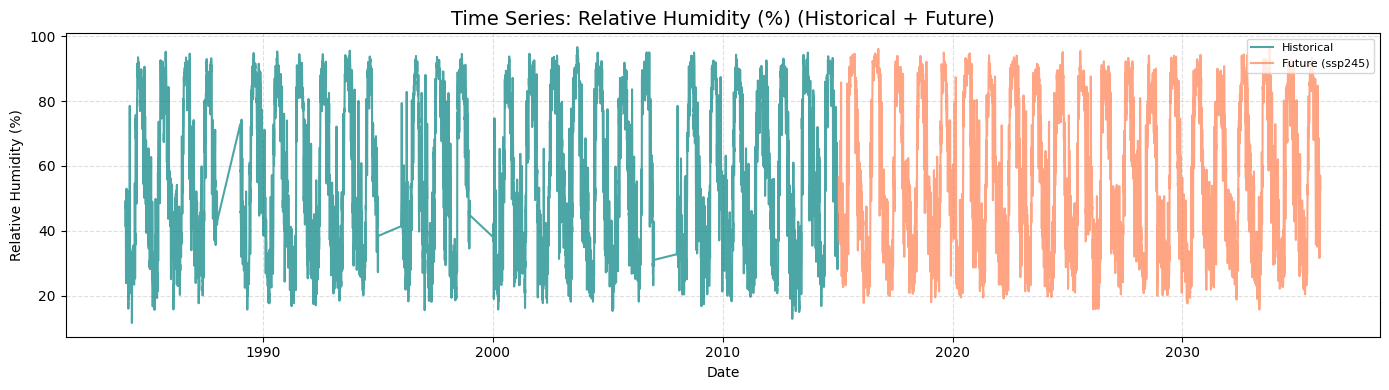

✓ Saved visualizations/timeseries_Relative_Humidity.png


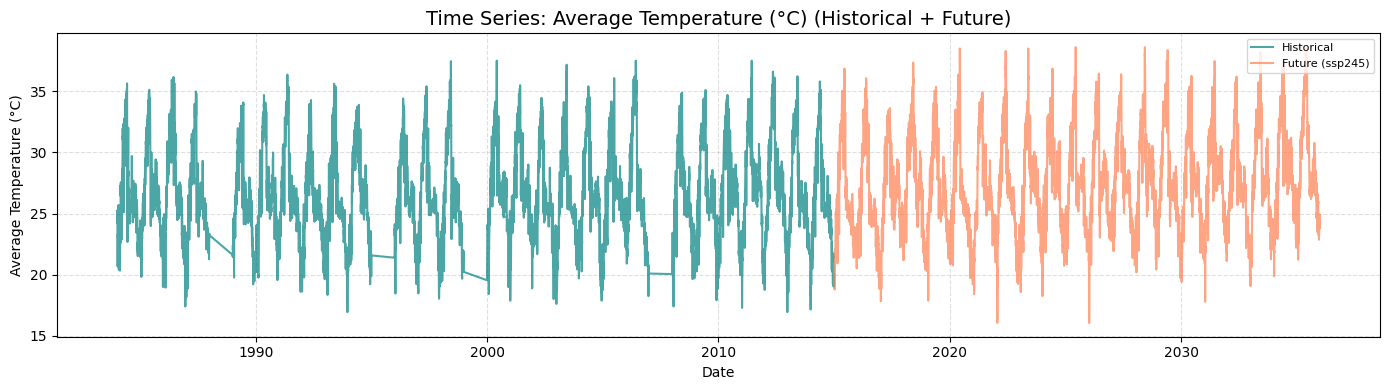

✓ Saved visualizations/timeseries_Average_Temperature_C.png


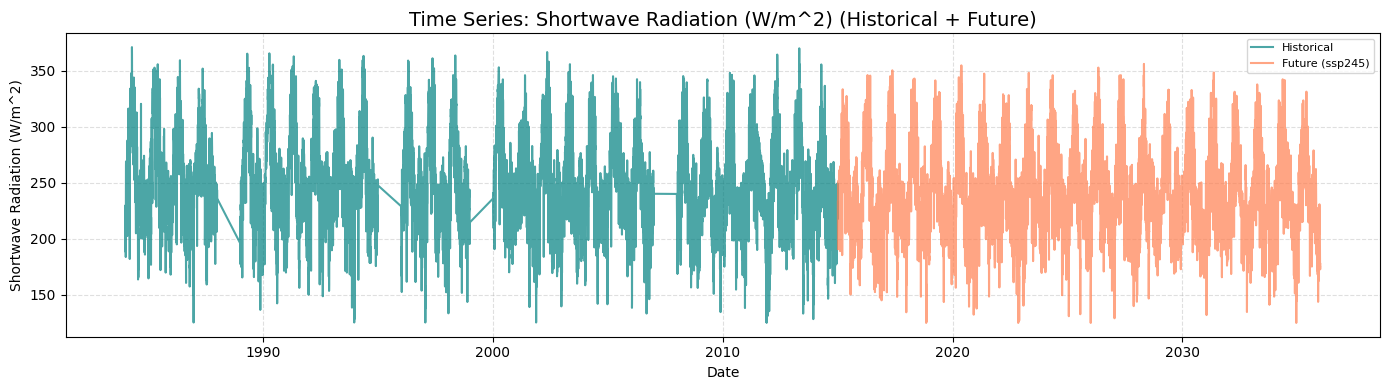

✓ Saved visualizations/timeseries_Shortwave_Radiation_W_m_2.png


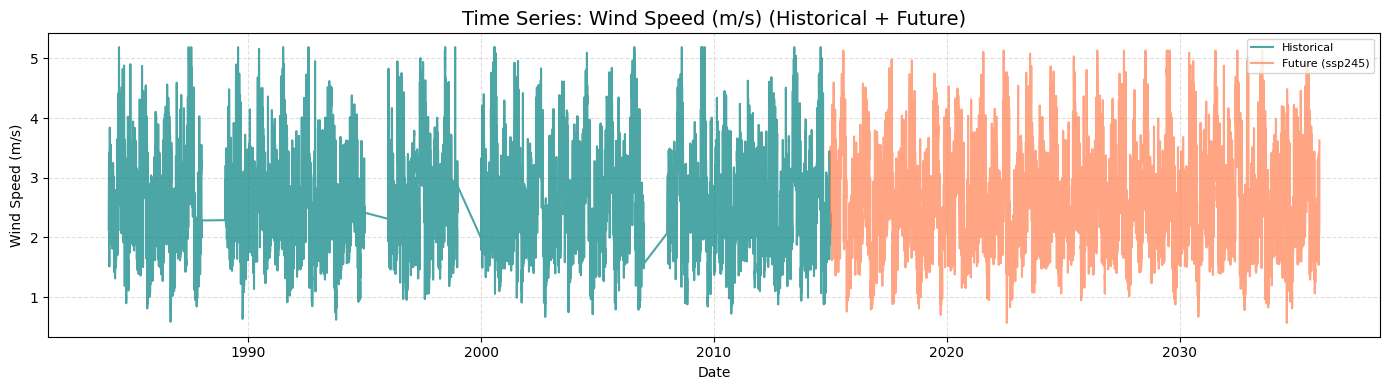

✓ Saved visualizations/timeseries_Wind_Speed_m_s.png


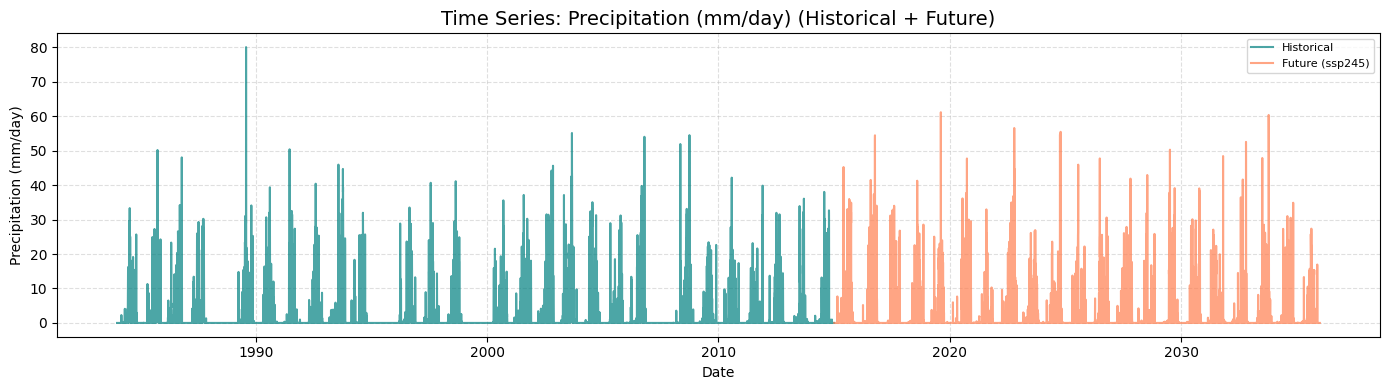

✓ Saved visualizations/timeseries_Precipitation_mm_day.png


In [33]:
import re

# ---- Time Series Plots ----
for var in plot_vars:
    fig, ax = plt.subplots(figsize=(14, 4))
    
    # Plot historical and future data
    ax.plot(hist_df['time'], hist_df[var], color='teal', alpha=0.7, label='Historical')
    ax.plot(future_df['time'], future_df[var], color='coral', alpha=0.7, label='Future (ssp245)')
    
    # Formatting
    ax.set_title(f"Time Series: {var} (Historical + Future)", fontsize=14)
    ax.set_ylabel(var, fontsize=10)
    ax.set_xlabel("Date", fontsize=10)
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.4)
    
    plt.tight_layout()
    
    # Create a safe filename (e.g., "Average Temperature (°C)" -> "Average_Temperature_C")
    safe_var_name = re.sub(r'[^A-Za-z0-9]+', '_', var).strip('_')
    filename = f"visualizations/timeseries_{safe_var_name}.png"
    
    # Save and show
    plt.savefig(filename, dpi=200)
    plt.show()
    print(f"✓ Saved {filename}")

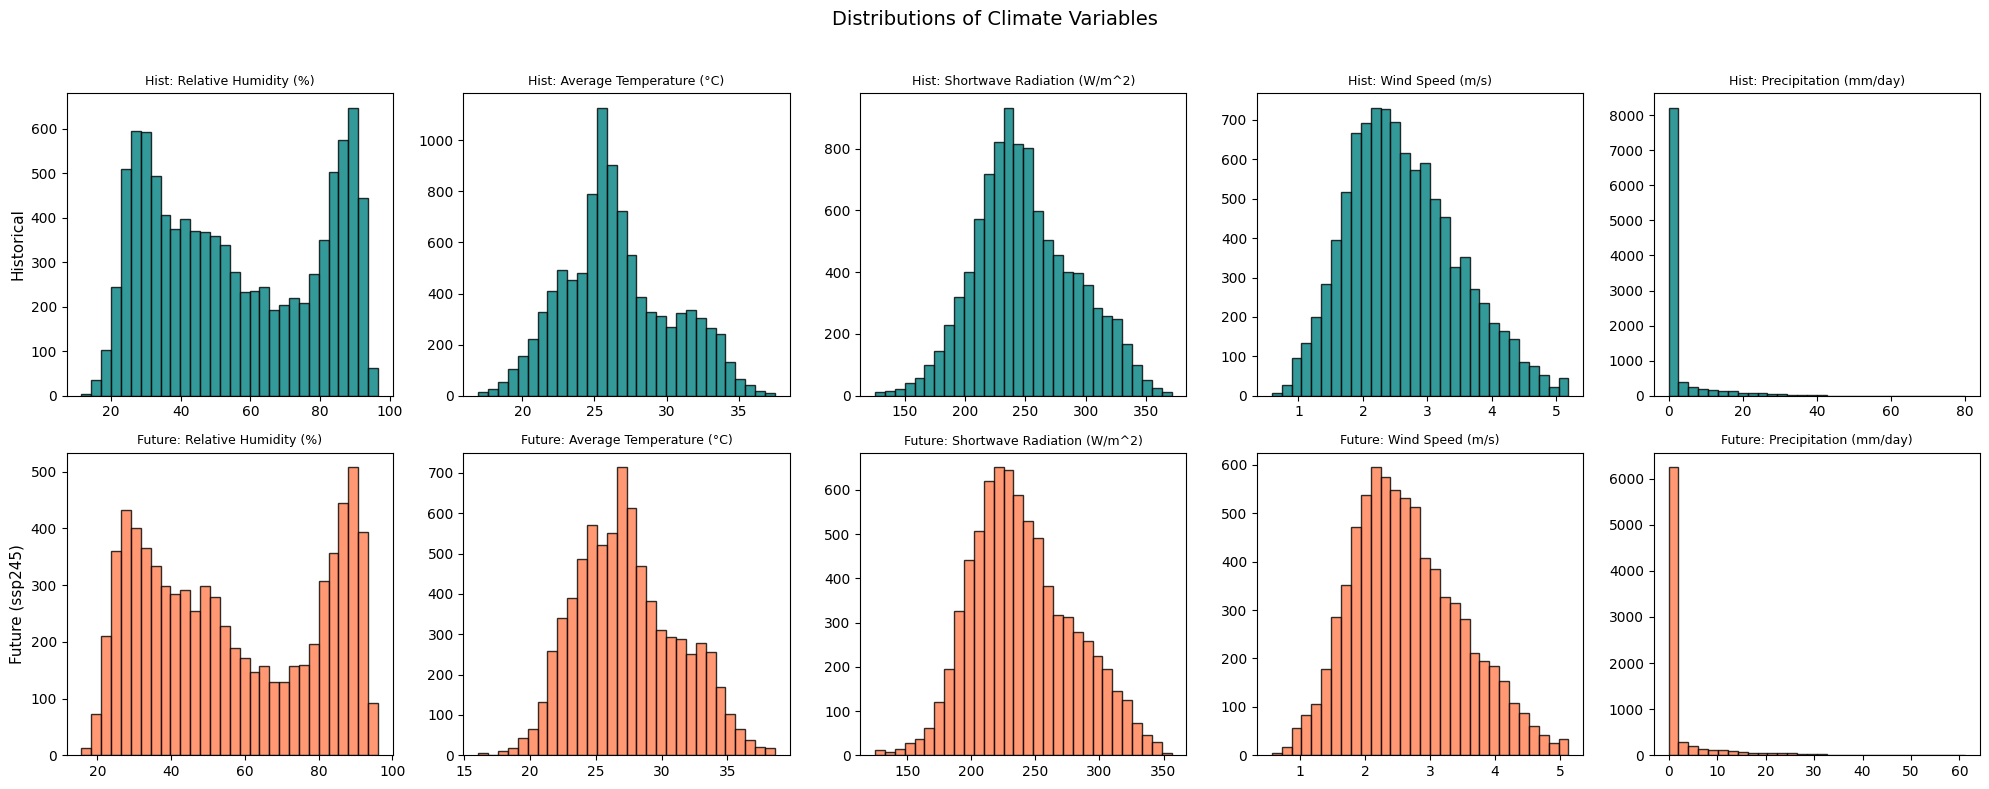

✓ Saved distributions.png


In [34]:
# ---- Distribution Histograms ----
fig, axes = plt.subplots(2, len(plot_vars), figsize=(4 * len(plot_vars), 8))
for j, var in enumerate(plot_vars):
    axes[0, j].hist(hist_df[var], bins=30, color='teal', edgecolor='black', alpha=0.8)
    axes[0, j].set_title(f"Hist: {var}", fontsize=9)
    axes[1, j].hist(future_df[var], bins=30, color='coral', edgecolor='black', alpha=0.8)
    axes[1, j].set_title(f"Future: {var}", fontsize=9)
axes[0, 0].set_ylabel("Historical", fontsize=11)
axes[1, 0].set_ylabel("Future (ssp245)", fontsize=11)
plt.suptitle("Distributions of Climate Variables", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("visualizations/distributions.png", dpi=200)
plt.show()
print("✓ Saved distributions.png")

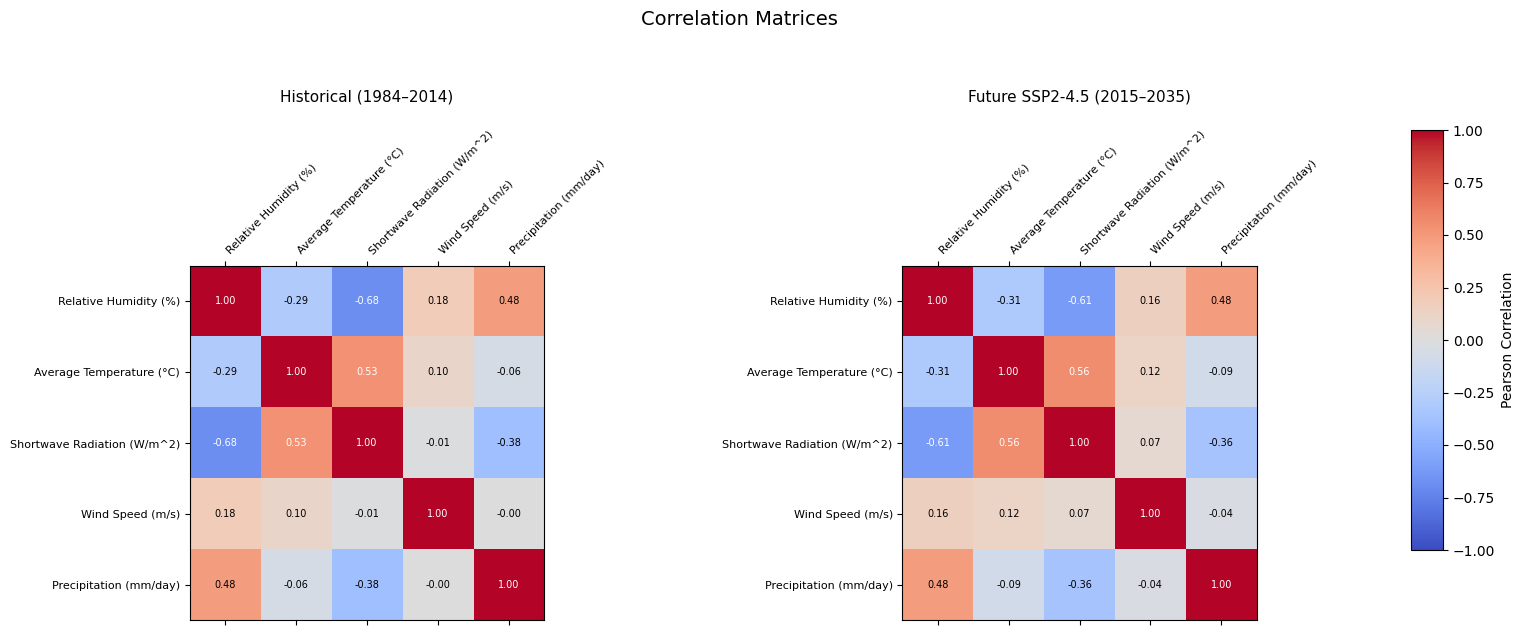

✓ Saved correlation_matrices.png


In [35]:
# ---- Correlation Matrix ----
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, df, title in zip(axes, [hist_df, future_df], ['Historical (1984–2014)', 'Future SSP2-4.5 (2015–2035)']):
    corr = df[plot_vars].corr()
    im = ax.matshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
    ax.set_xticks(range(len(plot_vars)))
    ax.set_xticklabels(plot_vars, fontsize=8, rotation=45, ha='left')
    ax.set_yticks(range(len(plot_vars)))
    ax.set_yticklabels(plot_vars, fontsize=8)
    for (i, j), z in np.ndenumerate(corr.values):
        ax.text(j, i, f'{z:.2f}', ha='center', va='center', fontsize=7,
                color='white' if abs(z) >= 0.5 else 'black')
    ax.set_title(title, pad=20, fontsize=11)

plt.suptitle("Correlation Matrices", fontsize=14, y=1.05)

# 1. Apply tight_layout, but reserve the right 10% of the figure (0.90) for the colorbar
plt.tight_layout(rect=[0, 0, 0.90, 1])

# 2. Create a dedicated axis for the colorbar to prevent any overlapping
# Coordinates: [left, bottom, width, height]
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])

# 3. Draw the colorbar in the new dedicated axis
fig.colorbar(im, cax=cbar_ax, label='Pearson Correlation')

# bbox_inches='tight' ensures the suptitle and slanted labels aren't cut off
plt.savefig("visualizations/correlation_matrices.png", dpi=200, bbox_inches='tight')
plt.show()
print("✓ Saved correlation_matrices.png")

---
## Step 6: Build ML Models on Historical Data

**Target:** Precipitation (mm/day)  
**Predictors:** Relative Humidity, Average Temperature, Min Temperature, Max Temperature, Wind Speed  
**Models:** Linear Regression, Random Forest Regressor  
**Pre-processing:** StandardScaler normalization

In [37]:
from sklearn.model_selection import RandomizedSearchCV

# Load historical CSV
hist_df = pd.read_csv("historical_data.csv")
hist_df['time'] = pd.to_datetime(hist_df['time'])
hist_df.dropna(inplace=True)

# ---- UPDATED PREDICTORS ----
predictors = [
    "Relative Humidity (%)",
    "Average Temperature (°C)",
    "Shortwave Radiation (W/m^2)",
    "Wind Speed (m/s)",
    "Rainfall Lag 1 (mm/day)",
    "Rainfall Lag 2 (mm/day)"
]
target = "Precipitation (mm/day)"

X = hist_df[predictors]
y = hist_df[target]

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 80/20 split
# Note: For time-series data, shuffle=False prevents "data leakage" (predicting the past using the future)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, shuffle=False
)

# ---- Random Forest with Hyperparameter Tuning ----
print("Tuning Random Forest hyperparameters... (this may take a minute or two)")

# Define the parameter grid to search
rf_param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 1.0] # 1.0 means all features
}

# Initialize base model
rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

# Initialize Randomized Search (tests 15 random combinations using 3-fold cross-validation)
rf_random = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=rf_param_grid,
    n_iter=15, 
    cv=3,      
    verbose=1,
    random_state=42,
    n_jobs=-1,
    scoring='neg_mean_squared_error'
)

# Fit the random search model
rf_random.fit(X_train, y_train)

# Get the best model from the search
rf = rf_random.best_estimator_

print(f"\n✓ Best Parameters found: {rf_random.best_params_}\n")

# Predict using the optimized model
rf_pred = rf.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("="*60)
print("   OPTIMIZED RANDOM FOREST — Historical Validation")
print("="*60)
print(f"  R² Score : {rf_r2:.4f}")
print(f"  RMSE     : {rf_rmse:.4f} mm/day")
print("\n  Feature Importances:")
for name, imp in zip(predictors, rf.feature_importances_):
    print(f"    {name:35s} : {imp:.6f}")

# ---- Summary Table ----
print("\n" + "="*60)
print("   MODEL SUMMARY")
print("="*60)
summary = pd.DataFrame({
    'Model': ['Optimized Random Forest'],
    'R² Score': [rf_r2],
    'RMSE (mm/day)': [rf_rmse]
})
display(summary)

Tuning Random Forest hyperparameters... (this may take a minute or two)
Fitting 3 folds for each of 15 candidates, totalling 45 fits

✓ Best Parameters found: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 20}

   OPTIMIZED RANDOM FOREST — Historical Validation
  R² Score : 0.6975
  RMSE     : 3.0763 mm/day

  Feature Importances:
    Relative Humidity (%)               : 0.380462
    Average Temperature (°C)            : 0.068311
    Shortwave Radiation (W/m^2)         : 0.104443
    Wind Speed (m/s)                    : 0.055796
    Rainfall Lag 1 (mm/day)             : 0.282442
    Rainfall Lag 2 (mm/day)             : 0.108546

   MODEL SUMMARY


,Model,R² Score,RMSE (mm/day)
0,Optimized Random Forest,0.697471,3.076268


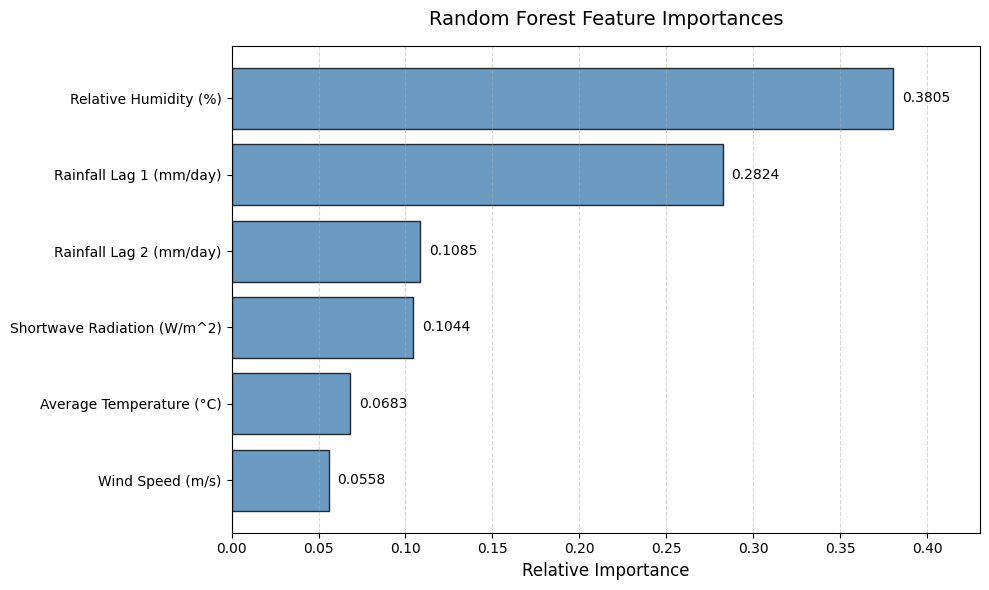

✓ Saved feature_importances.png


In [39]:
# ---- Feature Importance Plot ----
# Create a DataFrame for easier sorting
feat_imp_df = pd.DataFrame({
    'Feature': predictors,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=True) # Sort ascending so the highest is at the top of the horizontal bar chart

fig, ax = plt.subplots(figsize=(10, 6))

# Create horizontal bar chart
bars = ax.barh(feat_imp_df['Feature'], feat_imp_df['Importance'], color='steelblue', edgecolor='black', alpha=0.8)

# Formatting
ax.set_xlabel('Relative Importance', fontsize=12)
ax.set_title('Random Forest Feature Importances', fontsize=14, pad=15)
ax.grid(axis='x', linestyle='--', alpha=0.5)

# Add the exact values at the end of each bar for readability
for index, value in enumerate(feat_imp_df['Importance']):
    ax.text(value + 0.005, index, f'{value:.4f}', va='center', fontsize=10)

# Expand x-axis limit slightly so the text doesn't get cut off
ax.set_xlim(0, feat_imp_df['Importance'].max() + 0.05)

plt.tight_layout()
plt.savefig("visualizations/feature_importances.png", dpi=200)
plt.show()
print("✓ Saved feature_importances.png")

---
## Step 7: Test Models Against Future Data & Comparative Plot

   FUTURE TESTING — Model vs GCM Simulated Precipitation


,Model,Future R²,Future RMSE (mm/day)
0,Random Forest,0.666897,3.764927


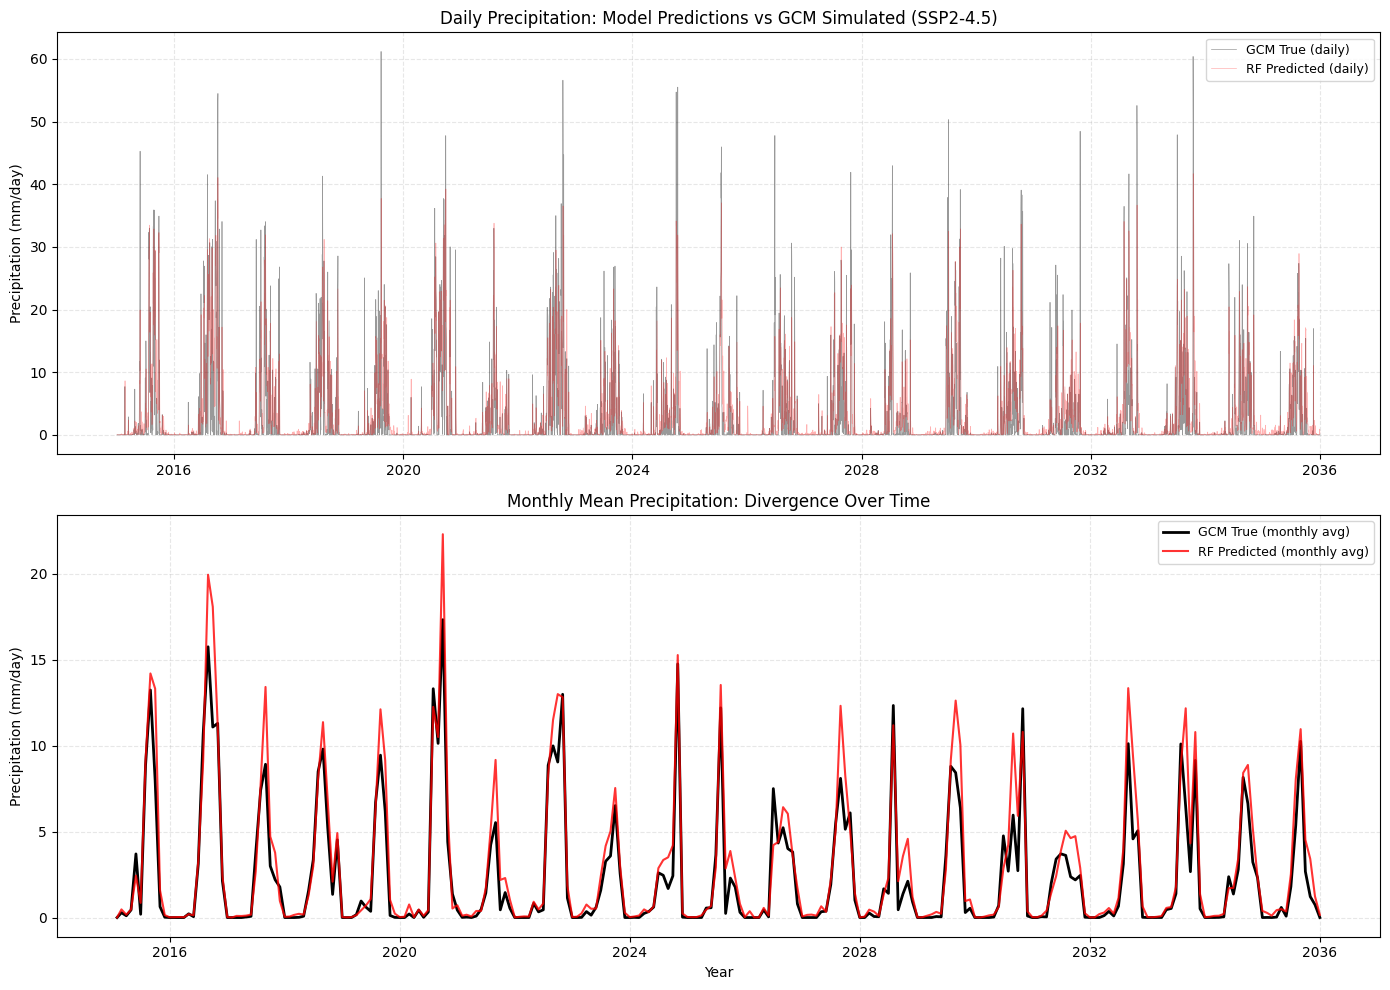

✓ Saved future_model_comparison.png


In [38]:
# Load future CSV
future_df = pd.read_csv("future_data.csv")
future_df['time'] = pd.to_datetime(future_df['time'])
future_df.dropna(inplace=True)

X_future = future_df[predictors]
y_future_true = future_df[target]

# Scale using the SAME scaler fitted on historical data
X_future_scaled = scaler.transform(X_future)

# Predict using Random Forest ONLY
rf_future = rf.predict(X_future_scaled)

# ---- Future Accuracy Metrics ----
print("="*60)
print("   FUTURE TESTING — Model vs GCM Simulated Precipitation")
print("="*60)

rf_f_rmse = np.sqrt(mean_squared_error(y_future_true, rf_future))
rf_f_r2 = r2_score(y_future_true, rf_future)

future_summary = pd.DataFrame({
    'Model': ['Random Forest'],
    'Future R²': [rf_f_r2],
    'Future RMSE (mm/day)': [rf_f_rmse]
})
display(future_summary)

# ---- Yearly Moving Average for cleaner plot ----
result_df = pd.DataFrame({
    'time': future_df['time'],
    'GCM True': y_future_true.values,
    'RF Predicted': rf_future
}).set_index('time')

# Resample to monthly means for a cleaner trend view
monthly = result_df.resample('M').mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Daily values (raw)
axes[0].plot(result_df.index, result_df['GCM True'], color='black', alpha=0.4, linewidth=0.5, label='GCM True (daily)')
axes[0].plot(result_df.index, result_df['RF Predicted'], color='red', alpha=0.3, linewidth=0.5, label='RF Predicted (daily)')
axes[0].set_title("Daily Precipitation: Model Predictions vs GCM Simulated (SSP2-4.5)", fontsize=12)
axes[0].set_ylabel("Precipitation (mm/day)")
axes[0].legend(fontsize=9)
axes[0].grid(True, linestyle='--', alpha=0.3)

# Plot 2: Monthly means (trend)
axes[1].plot(monthly.index, monthly['GCM True'], color='black', linewidth=2, label='GCM True (monthly avg)')
axes[1].plot(monthly.index, monthly['RF Predicted'], color='red', linewidth=1.5, alpha=0.8, label='RF Predicted (monthly avg)')
axes[1].set_title("Monthly Mean Precipitation: Divergence Over Time", fontsize=12)
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Precipitation (mm/day)")
axes[1].legend(fontsize=9)
axes[1].grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig("visualizations/future_model_comparison.png", dpi=200)
plt.show()
print("✓ Saved future_model_comparison.png")